# 09 · Expected Loss, cartera y stress testing — Caso 15 · Caja Rural 360

**Alcance:** sección **6.12**. Narrativa en `reports/12_expected_loss_stress.md`. El tablero se genera en `reports/dashboard_cartera.html`.

Aquí se juntan las tres piezas: **PD calibrada** (6.7), **factor de exposición** (6.10) y **LGD** (6.11).

    EL_i = PD_i × (EAD_i / monto_i) × LGD_i × monto_i

**Dos decisiones que se toman en esta sección:**

1. **Base de la LGD.** 6.11 mostró que la LGD del archivo no descuenta y que hacerlo la sube entre 6% y 15%. Aquí se adopta la **LGD económica**, descontada a la tasa efectiva de los créditos que la política realmente colocaría, y se **restatea el umbral de pérdida esperada del apetito en esa misma base**. Cambiar la métrica sin cambiar el umbral rompería el semáforo por definición y no por riesgo.
2. **Capital de riesgo.** Se aproxima con la fórmula IRB de Basilea para *other retail*, que da la pérdida inesperada al 99.9%. No es el capital regulatorio del producto: es una vara común para comparar escenarios en unidades de capital y no solo de pérdida esperada.

**Población de análisis:** todas las solicitudes de **2025** con la política de 6.9 aplicada. Es la cosecha más reciente y la que representa la cartera que se colocaría.

| Sección | Contenido |
|---|---|
| 1 | Base de la LGD y restateo del umbral del apetito |
| 2 | Expected Loss a nivel cliente y de cartera |
| 3 | Tablero de cartera por segmento y concentración |
| 4 | Escenarios Base, Adverse y Severe |
| 5 | Capital de riesgo y el estabilizador automático de la política |
| 6 | Recomendación ejecutiva: capacidad de crecimiento y segmentos |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, decision as dec, eda, evaluation as ev, fairness as fr, features, models, pipeline, scorecard as sc, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
from src import decision as dec, evaluation as ev, portfolio as pf, scorecard as sc, severity as sv
raw = data.load_raw(); pop, _ = data.pd_population(raw)
fx = features.build_features(pop); T = cfg.TARGET
dev, val = fx[fx["sample"] == "DEV"], fx[fx["sample"] == "VAL"]
card = sc.Scorecard.load(cfg.ROOT / "models" / "scorecard_pd_v1.json")
platt = ev.PlattCalibrator().fit(card.predict_pd(val), val[T])
pd_calibrada = lambda d: platt.transform(card.predict_pd(d))
politica = dec.DecisionPolicy()
sev = sv.build_severity_frame(fx)
sev_dev, sev_dv = sev[sev["sample"] == "DEV"], sev[sev["sample"].isin(["DEV", "VAL"])]

ttd = features.build_features(raw[raw[cfg.DATE_COL].dt.year == 2025])
pd_ttd = pd_calibrada(ttd)
decisiones = politica.decide(ttd, pd_ttd, recalcular_pd=pd_calibrada)
peso = np.where(decisiones["decision"].eq("APPROVE"), 1.0,
                np.where(decisiones["decision"].eq("REVIEW"), cfg.REVIEW_APPROVAL_RATE, 0.0))
monto_colocado = decisiones["monto_recomendado"].fillna(0).to_numpy() * peso
print(f"Solicitudes 2025: {len(ttd):,} | aprobación final esperada {peso.mean():.1%} | monto colocado S/ {monto_colocado.sum():,.0f}")

Solicitudes 2025: 1,457 | aprobación final esperada 64.7% | monto colocado S/ 6,176,001


## 1. Base de la LGD y restateo del umbral del apetito

In [3]:
tasa_politica = float(decisiones.loc[decisiones["decision"].eq("APPROVE"), "tasa_recomendada"].mean())
lgd_contable = float(sev_dev["lgd"].mean())
lgd_economica = float(sv.lgd_economica(sev_dev, tasa_politica).mean())
factor = lgd_economica / lgd_contable
sev_dv = sev_dv.assign(lgd_econ=sv.lgd_economica(sev_dv, tasa_politica))
lgd_downturn = float(sev_dv.groupby(sev_dv[cfg.DATE_COL].dt.year)["lgd_econ"].mean().max())

umbrales = pd.DataFrame({
    "base contable (6.1)": {"verde": 0.030, "rojo": 0.035},
    "base económica (restateada)": {"verde": 0.030 * factor, "rojo": 0.035 * factor}}).T
display(umbrales)
print(f"Tasa efectiva de la política: {tasa_politica:.1%} | LGD contable {lgd_contable:.4f} -> económica {lgd_economica:.4f} (factor {factor:.3f})")
print(f"LGD de downturn en base económica: {lgd_downturn:.4f} (+{(lgd_downturn - lgd_economica) * 100:.1f} pp)")

perdida_hist = (fx[fx[T].eq(1)].groupby(fx[fx[T].eq(1)][cfg.DATE_COL].dt.year)
                .apply(lambda g: (g["ead_at_default"] * g["lgd_observed"]).sum()) /
                fx.groupby(fx[cfg.DATE_COL].dt.year)["requested_amount"].sum())
hist = pd.DataFrame({"pérdida realizada (contable)": perdida_hist, "pérdida realizada (económica)": perdida_hist * factor})
display(hist.round(4))
umbrales.to_csv(cfg.TABLES / "el_umbrales_restateados.csv")

,verde,rojo
base contable (6.1),0.0300,0.0350
base económica (restateada),0.0334,0.0389


Tasa efectiva de la política: 20.2% | LGD contable 0.6164 -> económica 0.6858 (factor 1.113)
LGD de downturn en base económica: 0.6954 (+1.0 pp)


,pérdida realizada (contable),pérdida realizada (económica)
observation_date,,
2021,0.0189,0.0210
2022,0.0234,0.0261
2023,0.0300,0.0333
2024,0.0401,0.0447
2025,0.0337,0.0375


**Decisión: base económica, con el umbral restateado.** Descontar a la tasa efectiva que cobraría la política (20.2%) lleva la LGD de 0.616 a 0.686, un factor de **1.113**. Aplicado al apetito, el umbral de pérdida esperada pasa de **3.0% a 3.34% en verde** y de 3.5% a **3.89% en rojo**.

El restateo no es un truco para pasar el semáforo: es la condición para que la comparación tenga sentido. De hecho, mirado en la base correcta, **la política histórica ya venía incumpliendo**: su pérdida realizada de 2024 equivale a 4.46% en base económica, muy por encima del rojo restateado.

## 2. Expected Loss a nivel cliente y de cartera

,monto,pd,ead_factor,ead,lgd,el
32,"8,160.0000",0.1400,0.4200,"3,386.4000",0.6900,334.4600
52,"7,854.5900",0.1200,0.4200,"3,259.6500",0.6900,257.8000
54,"3,563.1800",0.1400,0.4200,"1,478.7200",0.6900,143.9600
59,"4,425.5400",0.1300,0.4200,"1,836.6000",0.6900,158.0700
60,"6,660.1500",0.0400,0.4200,"2,763.9600",0.6900,73.3900


,creditos,monto,ead,pd_ponderada,lgd_ponderada,el,el_sobre_monto
cartera 2025 con la política propuesta,"1,022.0000","6,176,000.7020","2,563,040.2913",0.1051,0.6858,"184,657.4214",0.0299


,creditos,monto,pd_media,el,pct_monto,pct_el,el_sobre_monto,pct_el_acumulado
pd,,,,,,,,
1,103,"445,350.0880",0.1828,"23,110.4751",0.0721,0.1252,0.0519,0.1252
2,102,"631,665.0060",0.1595,"28,693.1853",0.1023,0.1554,0.0454,0.2805
3,102,"558,191.2460",0.1402,"22,174.5469",0.0904,0.1201,0.0397,0.4006
4,102,"637,935.0820",0.1251,"22,702.6862",0.1033,0.1229,0.0356,0.5236
5,102,"687,087.9860",0.1089,"21,264.5192",0.1113,0.1152,0.0309,0.6387
6,102,"611,506.7080",0.1013,"17,604.3020",0.0990,0.0953,0.0288,0.7341
7,102,"667,401.5580",0.0902,"17,255.6115",0.1081,0.0934,0.0259,0.8275
8,102,"552,036.0420",0.0769,"12,099.6873",0.0894,0.0655,0.0219,0.8930
9,102,"713,893.6100",0.0569,"11,468.0580",0.1156,0.0621,0.0161,0.9551


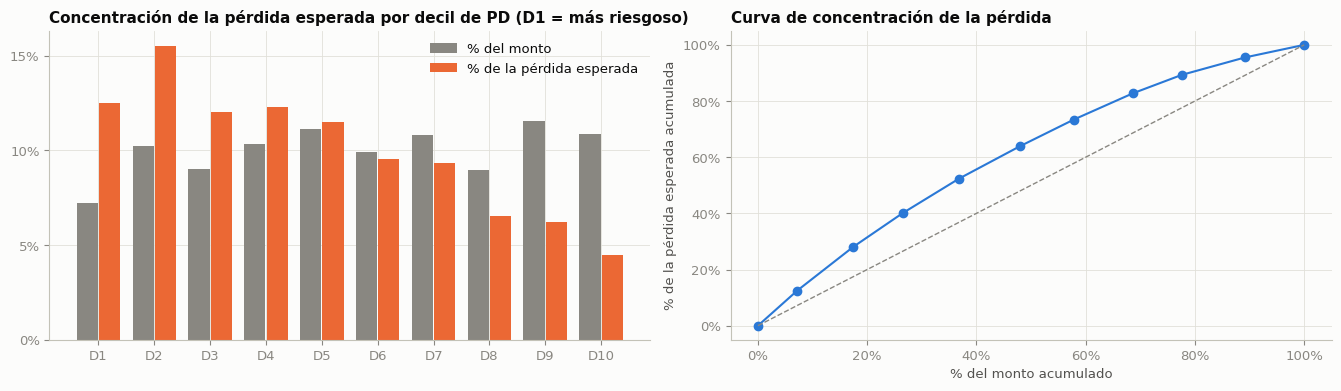

In [4]:
el = pf.expected_loss_frame(ttd, pd_ttd, monto=monto_colocado, ead_factor=cfg.EAD_FACTOR_BASELINE, lgd=lgd_economica)
colocados = el[el["monto"] > 0]
display(colocados.head(5).round(2))
resumen = pf.portfolio_summary(colocados)
display(pd.Series(resumen).to_frame("cartera 2025 con la política propuesta").T)

deciles = pd.qcut(colocados["pd"].rank(method="first", ascending=False), 10, labels=range(1, 11))
conc = colocados.groupby(deciles).agg(creditos=("el", "size"), monto=("monto", "sum"), pd_media=("pd", "mean"), el=("el", "sum"))
conc["pct_monto"] = conc["monto"] / conc["monto"].sum()
conc["pct_el"] = conc["el"] / conc["el"].sum()
conc["el_sobre_monto"] = conc["el"] / conc["monto"]
conc["pct_el_acumulado"] = conc["pct_el"].cumsum()
display(conc.round(4))
conc.to_csv(cfg.TABLES / "el_concentracion_deciles.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4))
x = np.arange(len(conc))
axes[0].bar(x - 0.2, conc["pct_monto"], width=0.38, color=MUTED, label="% del monto")
axes[0].bar(x + 0.2, conc["pct_el"], width=0.38, color=ORANGE, label="% de la pérdida esperada")
axes[0].set_xticks(x, [f"D{i}" for i in conc.index]); pct_axis(axes[0]); axes[0].legend()
axes[0].set_title("Concentración de la pérdida esperada por decil de PD (D1 = más riesgoso)")
axes[1].plot(np.r_[0, conc["pct_monto"].cumsum()], np.r_[0, conc["pct_el_acumulado"]], marker="o", color=BLUE)
axes[1].plot([0, 1], [0, 1], color=MUTED, ls="--", lw=1)
axes[1].set_xlabel("% del monto acumulado"); axes[1].set_ylabel("% de la pérdida esperada acumulada")
pct_axis(axes[1]); pct_axis(axes[1], axis="x"); axes[1].set_title("Curva de concentración de la pérdida")
fig.tight_layout(); savefig(fig, "fig31_el_concentracion"); plt.show()

## 3. Tablero de cartera por segmento

In [5]:
segmentos = {
    "Banda de score": pd.cut(pd.Series(card.score(ttd), index=ttd.index), [-np.inf, 560, 580, 600, 620, 640, np.inf],
                             labels=["<= 560", "560-580", "580-600", "600-620", "620-640", "> 640"]).astype(str),
    "Región": ttd["region"], "Canal": ttd["channel"],
    "Tramo de monto": pd.cut(ttd["requested_amount"], [0, 5000, 10000, 20000, np.inf],
                             labels=["<= 5k", "5k-10k", "10k-20k", "> 20k"]).astype(str),
    "Capacidad (DTI post)": pd.cut(ttd["dti_post"], [0, 0.30, 0.45, 0.60, np.inf],
                                   labels=["<= 30%", "30-45%", "45-60%", "> 60%"]).astype(str),
    "Ingreso en efectivo": pd.cut(ttd["cash_income_share"], [0, 0.4, 0.8, 1.0],
                                  labels=["<= 40%", "40-80%", "> 80%"]).astype(str),
}
y_obs = np.where(ttd[cfg.OUTCOME_FILTER].eq(1), ttd[T], np.nan)
tablero = pf.segment_dashboard(ttd[monto_colocado > 0], el[monto_colocado > 0],
                               {k: v[monto_colocado > 0] for k, v in segmentos.items()}, y_obs[monto_colocado > 0])
# Rentabilidad por segmento: margen menos pérdida esperada
margen = dec.expected_margin(ttd, decisiones["tasa_recomendada"].fillna(0).to_numpy(), monto_colocado)
extra = []
for nombre, serie in segmentos.items():
    g = pd.DataFrame({"seg": serie[monto_colocado > 0].astype(str).to_numpy(),
                      "margen": margen[monto_colocado > 0], "monto": monto_colocado[monto_colocado > 0],
                      "el": el.loc[monto_colocado > 0, "el"].to_numpy()})
    t = g.groupby("seg").apply(lambda x: pd.Series({
        "margen_sobre_monto": x["margen"].sum() / x["monto"].sum(),
        "resultado_sobre_monto": (x["margen"].sum() - x["el"].sum()) / x["monto"].sum()}))
    t.insert(0, "dimension", nombre); extra.append(t)
tablero = tablero.join(pd.concat(extra)[["margen_sobre_monto", "resultado_sobre_monto"]])
display(tablero.round(4))
tablero.to_csv(cfg.TABLES / "el_tablero_segmentos.csv")
print("Concentración (HHI) del monto colocado:",
      {d: round(pf.hhi(tablero[tablero.dimension == d]["pct_monto"]), 3) for d in segmentos})

,dimension,creditos,monto,pct_monto,pd_ponderada,ead,lgd,el,el_sobre_monto,pct_el,default_observado,margen_sobre_monto,resultado_sobre_monto
seg,,,,,,,,,,,,,
600-620,Banda de score,428.0000,"2,805,392.1480",0.4542,0.1084,"1,164,237.7414",0.6858,"86,564.8052",0.0309,0.4688,0.0943,0.1044,0.0736
580-600,Banda de score,271.0000,"1,405,852.8040",0.2276,0.1627,"583,428.9137",0.6858,"65,100.7366",0.0463,0.3525,0.1611,0.1006,0.0543
620-640,Banda de score,184.0000,"1,045,013.6740",0.1692,0.0694,"433,680.6747",0.6858,"20,636.5819",0.0197,0.1118,0.0427,0.0900,0.0703
> 640,Banda de score,135.0000,"910,957.0140",0.1475,0.0451,"378,047.1608",0.6858,"11,682.3924",0.0128,0.0633,0.0248,0.0956,0.0828
560-580,Banda de score,4.0000,"8,785.0620",0.0014,0.2691,"3,645.8007",0.6858,672.9052,0.0766,0.0036,0.2500,0.1095,0.0329
Lima,Región,410.0000,"2,462,206.7780",0.3987,0.1033,"1,021,815.8129",0.6858,"72,354.2291",0.0294,0.3918,0.0798,0.0985,0.0691
Norte,Región,196.0000,"1,239,577.8700",0.2007,0.1067,"514,424.8160",0.6858,"37,652.5109",0.0304,0.2039,0.1065,0.1056,0.0752
Centro,Región,166.0000,"952,644.2460",0.1542,0.1063,"395,347.3621",0.6858,"28,825.4685",0.0303,0.1561,0.1223,0.0976,0.0674
Sur,Región,143.0000,"858,508.0360",0.1390,0.1029,"356,280.8349",0.6858,"25,153.1030",0.0293,0.1362,0.0714,0.0963,0.0670


Concentración (HHI) del monto colocado: {'Banda de score': 0.309, 'Región': 0.254, 'Canal': 0.298, 'Tramo de monto': 0.304, 'Capacidad (DTI post)': 0.311, 'Ingreso en efectivo': 0.478}


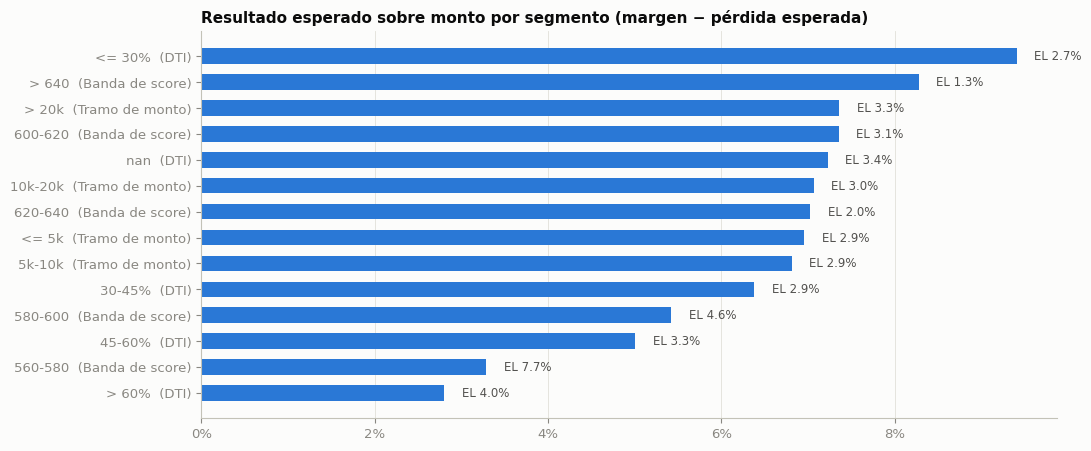

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.6))
t_ = tablero[tablero.dimension.isin(["Banda de score", "Capacidad (DTI post)", "Tramo de monto"])].copy()
t_["etiqueta"] = t_.index + "  (" + t_.dimension.str.replace("Capacidad (DTI post)", "DTI", regex=False) + ")"
t_ = t_.sort_values("resultado_sobre_monto")
colores = [BLUE if v > 0 else ORANGE for v in t_["resultado_sobre_monto"]]
ax.barh(t_["etiqueta"], t_["resultado_sobre_monto"], color=colores, height=0.6)
for y_, (v, el_) in enumerate(zip(t_["resultado_sobre_monto"], t_["el_sobre_monto"])):
    ax.text(v + 0.002, y_, f"EL {el_:.1%}", va="center", fontsize=8.5, color=INK_2)
pct_axis(ax, axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Resultado esperado sobre monto por segmento (margen − pérdida esperada)")
fig.tight_layout(); savefig(fig, "fig32_rentabilidad_segmentos"); plt.show()

## 4. Escenarios de stress

Los shocks no son redondos por gusto: cada uno se ata a algo observado en la propia cartera. El shock de PD se aplica sobre las **odds** y no sobre la PD, para que el deterioro sea proporcional en toda la distribución, que es como se observó entre 2021 y 2024 (6.4: desplazamiento de nivel con pendiente estable).

In [7]:
ead_trimestral = sev.groupby(sev[cfg.DATE_COL].dt.to_period("Q"))["ead_ratio"].mean()
escenarios = [
    pf.Escenario("Base", 1.0, lgd_economica, cfg.EAD_FACTOR_BASELINE,
                 "Nivel de riesgo actual: PD calibrada con VAL, LGD económica de largo plazo y exposición media"),
    pf.Escenario("Adverse", 1.44, lgd_downturn, round(float(ead_trimestral.quantile(0.90)), 3),
                 "Dos años más de la tendencia observada (odds x1.20 por año, 6.4), LGD de la peor cosecha y exposición del percentil 90 trimestral"),
    pf.Escenario("Severe", 2.0, round(lgd_downturn + 0.05, 4), round(float(ead_trimestral.max()), 3),
                 "Odds x2 (peor trimestre observado vs. mejor), recargo prudencial de 5 pp sobre la LGD de downturn y peor exposición trimestral"),
]
display(pd.DataFrame([{"escenario": e.nombre, "odds de PD": e.odds_pd, "LGD": e.lgd, "EAD/monto": e.ead_factor,
                       "justificación": e.justificacion} for e in escenarios]).set_index("escenario"))

resultados = pf.run_scenarios(ttd, pd_ttd, escenarios, politica, recalcular_pd=pd_calibrada)
display(resultados.drop(columns=["justificacion"]).round(4))
resultados.to_csv(cfg.TABLES / "el_escenarios.csv")

# ¿Cuánto absorbe la política? Mismo shock sobre la cartera del escenario base, sin volver a decidir.
congelada = []
for e in escenarios:
    p = e.pd_shock(pd_ttd)
    el_c = pf.expected_loss_frame(ttd, p, monto=monto_colocado, ead_factor=e.ead_factor, lgd=e.lgd)
    congelada.append({"escenario": e.nombre, "el_sobre_monto_cartera_congelada": el_c["el"].sum() / monto_colocado.sum()})
absorcion = resultados[["el_sobre_monto", "aprobacion_final"]].join(pd.DataFrame(congelada).set_index("escenario"))
absorcion["absorbido_por_la_politica"] = absorcion["el_sobre_monto_cartera_congelada"] - absorcion["el_sobre_monto"]
display(absorcion.round(4))
absorcion.to_csv(cfg.TABLES / "el_estabilizador.csv")

,odds de PD,LGD,EAD/monto,justificación
escenario,,,,
Base,1.0000,0.6858,0.4150,"Nivel de riesgo actual: PD calibrada con VAL, ..."
Adverse,1.4400,0.6954,0.4530,Dos años más de la tendencia observada (odds x...
Severe,2.0000,0.7454,0.4860,"Odds x2 (peor trimestre observado vs. mejor), ..."


,odds_pd,lgd,ead_factor,aprobacion_final,monto_colocado,pd_ponderada,default_esperado,el,el_sobre_monto,margen_sobre_monto,resultado_sobre_monto,capital_sobre_ead,capital
escenario,,,,,,,,,,,,,
Base,1.0000,0.6858,0.4150,0.6465,"6,176,000.7020",0.1051,0.1071,"184,657.4214",0.0299,0.0998,0.0699,0.0948,"243,029.6175"
Adverse,1.4400,0.6954,0.4530,0.4997,"4,920,638.6160",0.1242,0.1249,"192,497.5342",0.0391,0.1045,0.0654,0.1016,"226,416.8021"
Severe,2.0000,0.7454,0.4860,0.3646,"3,639,656.0000",0.1458,0.1462,"192,175.4041",0.0528,0.1098,0.0570,0.1152,"203,850.2502"


,el_sobre_monto,aprobacion_final,el_sobre_monto_cartera_congelada,absorbido_por_la_politica
escenario,,,,
Base,0.0299,0.6465,0.0299,0.0000
Adverse,0.0391,0.4997,0.0453,0.0061
Severe,0.0528,0.3646,0.0680,0.0152


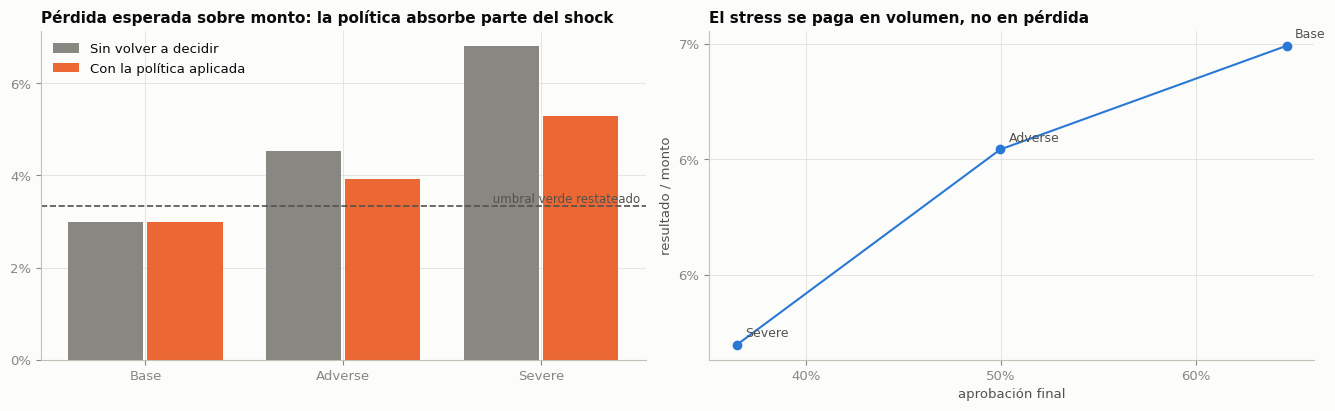

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
x = np.arange(len(resultados))
axes[0].bar(x - 0.2, absorcion["el_sobre_monto_cartera_congelada"], width=0.38, color=MUTED, label="Sin volver a decidir")
axes[0].bar(x + 0.2, absorcion["el_sobre_monto"], width=0.38, color=ORANGE, label="Con la política aplicada")
axes[0].axhline(0.030 * factor, color=INK_2, lw=1.2, ls="--")
axes[0].text(len(resultados) - 0.5, 0.030 * factor, " umbral verde restateado", ha="right", va="bottom", fontsize=8.5, color=INK_2)
axes[0].set_xticks(x, resultados.index); pct_axis(axes[0]); axes[0].legend(loc="upper left")
axes[0].set_title("Pérdida esperada sobre monto: la política absorbe parte del shock")
axes[1].plot(resultados["aprobacion_final"], resultados["resultado_sobre_monto"], marker="o", color=BLUE)
for n, r in resultados.iterrows():
    axes[1].annotate(n, (r["aprobacion_final"], r["resultado_sobre_monto"]), xytext=(6, 6),
                     textcoords="offset points", fontsize=9, color=INK_2)
pct_axis(axes[1]); pct_axis(axes[1], axis="x")
axes[1].set_xlabel("aprobación final"); axes[1].set_ylabel("resultado / monto")
axes[1].set_title("El stress se paga en volumen, no en pérdida")
fig.tight_layout(); savefig(fig, "fig33_escenarios"); plt.show()

**Lectura de los escenarios.**

- En **Base**, la cartera de 2025 tiene 2.99% de pérdida esperada sobre monto, por debajo del umbral verde restateado (3.34%), con 64.7% de aprobación y 7.0% de resultado.
- En **Adverse**, la pérdida esperada sube a 3.91% (rojo restateado) y la aprobación cae sola a 50.0%: los umbrales están en la escala de PD calibrada, así que un deterioro **reduce automáticamente la originación**.
- En **Severe**, la pérdida llega a 5.28% y la aprobación a 36.5%. El resultado sigue positivo (5.7%), pero el negocio se achica a la mitad.

**El dato que cambia la conversación:** si la cartera se congelara —mismo shock, sin volver a decidir— la pérdida esperada sería 4.53% en Adverse y **6.80%** en Severe. La política absorbe **0.6 y 1.5 puntos** respectivamente. Es un estabilizador automático, y es la razón por la que el corte debe expresarse en PD calibrada y no en score: si el corte fuera un puntaje fijo, el deterioro entraría entero a la cartera.

## 5. Capital de riesgo

In [9]:
cap = resultados[["capital_sobre_ead", "capital", "el_sobre_monto", "monto_colocado"]].copy()
cap["rwa_estimado"] = cap["capital"] * 12.5
cap["capital_mas_el_sobre_monto"] = (cap["capital"] + resultados["el"]) / cap["monto_colocado"]
display(cap.round(4))
cap.to_csv(cfg.TABLES / "el_capital.csv")
print("Correlación IRB other retail: R entre 3% y 16% según PD; confianza 99.9%.")

,capital_sobre_ead,capital,el_sobre_monto,monto_colocado,rwa_estimado,capital_mas_el_sobre_monto
escenario,,,,,,
Base,0.0948,"243,029.6175",0.0299,"6,176,000.7020","3,037,870.2182",0.0692
Adverse,0.1016,"226,416.8021",0.0391,"4,920,638.6160","2,830,210.0268",0.0851
Severe,0.1152,"203,850.2502",0.0528,"3,639,656.0000","2,548,128.1276",0.1088


Correlación IRB other retail: R entre 3% y 16% según PD; confianza 99.9%.


**Lectura.** El capital por pérdida inesperada pasa de 9.5% de la exposición en Base a 10.2% en Adverse y 11.5% en Severe. Sumando pérdida esperada y capital, el costo de riesgo total sobre el monto colocado va de 6.9% en Base a 8.5% en Adverse y 10.9% en Severe. La cartera **no queda descapitalizada en ningún escenario**, porque el achicamiento automático de la originación compensa el aumento del riesgo unitario, pero el Comité debe saber que un escenario Severe exige 2 puntos más de capital por sol prestado.

## 6. Recomendación ejecutiva y tablero

In [10]:
notas = ("Base de la LGD: económica, descontada a la tasa efectiva de la política. Umbral de pérdida esperada del "
         f"apetito restateado a {0.030 * factor:.2%} (verde) y {0.035 * factor:.2%} (rojo). "
         "PD calibrada con Platt sobre VAL; factor de exposición y LGD de 6.10 y 6.11.")
kpis = {"Solicitudes evaluadas": f"{len(ttd):,}", "Aprobación final": f"{peso.mean():.1%}",
        "Monto colocado": f"S/ {monto_colocado.sum():,.0f}", "PD ponderada": f"{resumen['pd_ponderada']:.1%}",
        "LGD (económica)": f"{lgd_economica:.1%}", "EAD / monto": f"{cfg.EAD_FACTOR_BASELINE:.1%}",
        "Pérdida esperada": f"S/ {resumen['el']:,.0f}", "EL / monto": f"{resumen['el_sobre_monto']:.2%}",
        "Capital (99.9%)": f"{resultados.loc['Base', 'capital_sobre_ead']:.1%} de la EAD"}
ruta = pf.build_dashboard(
    cfg.REPORTS / "dashboard_cartera.html", "Tablero de cartera y stress · Caja Rural 360 (cosecha 2025)", kpis,
    {"Cartera por segmento": tablero.round(4),
     "Escenarios de stress": resultados.drop(columns=["justificacion"]).round(4),
     "Absorción del shock por la política": absorcion.round(4),
     "Concentración de la pérdida por decil de PD": conc.round(4)},
    [cfg.FIGURES / f for f in ["fig31_el_concentracion.png", "fig32_rentabilidad_segmentos.png", "fig33_escenarios.png"]],
    notas)
print("Tablero generado:", Path(ruta).relative_to(cfg.ROOT), f"({Path(ruta).stat().st_size/1024:.0f} KB, autocontenido)")

Tablero generado: reports/dashboard_cartera.html (380 KB, autocontenido)


### Recomendación ejecutiva

**Capacidad de crecimiento.** Con la política de 6.9 y el nivel de riesgo actual, la Caja puede colocar la cosecha 2025 completa con 2.99% de pérdida esperada, dentro del apetito restateado, y un resultado de 7.0% sobre monto. El espacio para crecer **no está en subir el corte** —cada punto de aprobación adicional cuesta pérdida esperada y ya se cuantificó en 6.9— sino en tres palancas: verificar más rápido el ingreso (convierte revisiones en aprobaciones), re-consultar el buró de las solicitudes sin score, y crecer en los segmentos que abajo se priorizan.

**Segmentos a priorizar, con los números del tablero.** La capacidad de pago es la dimensión que más separa rentabilidad: con DTI post-crédito hasta 30% el resultado es **9.4%** sobre monto con 2.7% de pérdida esperada, contra 5.0% de resultado en el tramo 45-60% y **2.8%** por encima de 60%. En score, la banda sobre 640 rinde 8.3% con 1.3% de pérdida. Ahí está el crecimiento sano: clientes con holgura de cuota, no clientes con ticket grande.

**Lo que el tablero desmiente.** El tamaño del crédito **no** separa rentabilidad (todos los tramos rinden entre 6.8% y 7.4%), y el territorio tampoco: las cinco regiones quedan entre 6.7% y 7.5% de resultado, con Norte arriba y Sur abajo, es decir, diferencias de ruido. No hay una región que priorizar ni una que castigar, lo que además es coherente con el análisis de fairness de 6.8.

**Segmentos a vigilar o restringir.** La banda de score 580-600 concentra **35% de la pérdida esperada con 23% del monto** y rinde 5.4%: es la zona donde un deterioro pega primero, y es la que hay que recortar si el semáforo se pone en rojo. El DTI post-crédito sobre 60% rinde 2.8% y solo entra vía contraoferta. El ticket sobre S/ 20,000 rinde bien (7.4%), así que no se restringe por rentabilidad sino que se mantiene en revisión obligatoria por su comportamiento errático y su peso en la exposición (6.4).

**Qué mirar para actuar.** Si la pérdida esperada de la cosecha supera 3.34% (verde restateado), primero se revisa la calibración de la PD, no el corte: el 90% de las veces el problema es de nivel, no de ordenamiento. Si supera 3.89% (rojo), corresponde bajar el umbral de aprobación automática y escalar al Comité, con la curva de trade-off de 6.9 como insumo.

| Requisito 6.12 | Dónde |
|---|---|
| Integrar PD, EAD y LGD a nivel cliente y cartera | §2 · `portfolio.expected_loss_frame` |
| Tablero reproducible con exposición, PD, EAD, LGD, EL, aprobación, default y concentración | §3 y §6 · `reports/dashboard_cartera.html` · `el_tablero_segmentos.csv` |
| Tres escenarios con shocks definidos y justificados | §4 · `el_escenarios.csv` · `fig33` |
| Impacto en EL, aprobación, rentabilidad y capital | §4 y §5 · `el_capital.csv` · `el_estabilizador.csv` |
| Recomendación ejecutiva sobre crecimiento y segmentos | §6 |